In the Faster R-CNN architecture, the most important component that improved the speed compared to R-CNN and Fast R-CNN is the **Region Proposal Network (RPN)**.

Before introducing RPN, algorithms such as **Selective Search** were used to find object locations. These algorithms were slow and operated outside the neural network.

However, in Faster R-CNN, the generation of Region Proposals is also performed by a neural network. Therefore, the entire object detection process can be trained in an **End-to-End** manner.

# What Does RPN Do?

The input of RPN is the **Feature Map** extracted by the Backbone.

The overall process can be summarized as follows:

```

Image
│
▼
Backbone (ResNet)
│
Feature Map
│
▼
Region Proposal Network (RPN)
│
Region Proposals
│
Proposed Bounding Boxes

```

RPN does not operate directly on the image; instead, it works only on the **Feature Map**.

Its output is a set of Bounding Boxes where it predicts that an object is likely to exist.

An important point:

RPN does not determine what the object is.

It only says:

> "There is probably an Object here."

Therefore, the output of RPN is called **Object Proposal** or **Region Proposal**.
```


In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader
import torchvision
from torchvision.models.detection.image_list import ImageList

In [2]:
torch.cuda.is_available()

True

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
DEVICE

device(type='cuda')

In [5]:
IMAGE_DIR = 'dataset/images'
ANNOTATIONS_DIR = 'dataset/annotations'
TARGET_SIZE = (224, 224)
BATCH_SIZE = 8

In [6]:
class_names = [d for d in os.listdir(IMAGE_DIR) if os.path.isdir(os.path.join(IMAGE_DIR, d))]

In [7]:
class_names

['airplane', 'face', 'motorcycle']

In [8]:
csv_files = [f for f in os.listdir(ANNOTATIONS_DIR) if f.endswith('.csv')]

In [9]:
csv_files

['airplane.csv', 'face.csv', 'motorcycle.csv']

In [10]:
label_map = {name: i + 1 for i, name in enumerate(class_names)}

In [11]:
label_map

{'airplane': 1, 'face': 2, 'motorcycle': 3}

In [12]:
dataset = []

for i in range(len(class_names)):
    class_name = class_names[i]
    class_dir = os.path.join(IMAGE_DIR, class_name)
    csv_file_name = csv_files[i]
    
    csv_path = os.path.join(ANNOTATIONS_DIR, csv_file_name)
    df_annotations = pd.read_csv(csv_path)

    for image_name in os.listdir(class_dir):
        image_path = os.path.join(class_dir, image_name)
        
        image = cv2.imread(image_path)
        h, w, _ = image.shape

        ann = df_annotations[df_annotations['image_name'] == image_name].iloc[0,1:].tolist()
        
        ann[0] = (ann[0] / w) * 224
        ann[1] = (ann[1] / h) * 224
        ann[2] = (ann[2] / w) * 224
        ann[3] = (ann[3] / h) * 224

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))
        
        image_tensor = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
        label_tensor = torch.tensor([class_names.index(class_name)], dtype=torch.int64)
        ann_tensor = torch.tensor([ann], dtype=torch.float32)  # shape = [1, 4]

        target = {
            'boxes': ann_tensor,
            'labels': label_tensor
        }
        dataset.append((image_tensor, target))

def collate_fn(batch):
    return tuple(zip(*batch))

dataloader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)

# feature extraction

In [13]:
resnet_model = torchvision.models.resnet18()

In [14]:
from torchsummary import summary

In [15]:
summary(resnet_model,(3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [-1, 64, 112, 112]        128
├─ReLU: 1-3                              [-1, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [-1, 64, 56, 56]          --
├─Sequential: 1-5                        [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-1                   [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-3                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-6                    [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-2                   [-1, 64, 56, 56]          --
|

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [-1, 64, 112, 112]        128
├─ReLU: 1-3                              [-1, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [-1, 64, 56, 56]          --
├─Sequential: 1-5                        [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-1                   [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-3                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-6                    [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-2                   [-1, 64, 56, 56]          --
|

# Removing the Final Layers of ResNet

We are not performing Classification.

We only need the Feature Map.

Therefore, the last two layers of ResNet are removed.

As a result, the output of the Backbone will be a Feature Map instead of class predictions.

In [16]:
backbone = torch.nn.Sequential(*list(resnet_model.children())[:-2])
backbone.out_channels = 512 # custom attribute

In [17]:
backbone.out_channels

512

In [18]:
summary(backbone,(3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [-1, 64, 112, 112]        128
├─ReLU: 1-3                              [-1, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [-1, 64, 56, 56]          --
├─Sequential: 1-5                        [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-1                   [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-3                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-6                    [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-2                   [-1, 64, 56, 56]          --
|

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [-1, 64, 112, 112]        128
├─ReLU: 1-3                              [-1, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [-1, 64, 56, 56]          --
├─Sequential: 1-5                        [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-1                   [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-3                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-6                    [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-2                   [-1, 64, 56, 56]          --
|

# Freezing the Backbone

Usually, the Backbone is not trained.

It only extracts Features.

Therefore:

```python
parameter.requires_grad = False
````

is set.

This causes:

* Faster training speed.
* Lower memory consumption.
* More stable model training.

```
```


In [19]:
for param in backbone.parameters():
    param.requires_grad = False

# Main Components of RPN

RPN consists of three main components:

1. Anchor Generator
2. RPN Head
3. Non-Maximum Suppression (NMS)

Each of these components has a specific role.

---

# 1- Anchor Box

The first component of RPN is generating Anchor Boxes.

Anchor Boxes are initial rectangles placed on the Feature Map.

At each location of the Feature Map, multiple Anchors with different sizes and aspect ratios are generated.

For example:

```

32 × 32
64 × 64
128 × 128

```

For each size, we also have different aspect ratios:

```

1 : 1
1 : 2
2 : 1

```

As a result, 9 Anchors may be generated at each location.

For example:

```

3 Sizes

×

3 Aspect Ratios

=

9 Anchors

```

The purpose of Anchors is to cover objects with different sizes and shapes.

---

# 2- RPN Head

After generating Anchors, a small neural network called the RPN Head processes them.

This part performs two tasks for each Anchor.

## a) Classification

It determines whether the Anchor contains:

```

Object

or

Background

```

This probability is called the **Objectness Score**.

---

## b) Bounding Box Regression

If an Anchor is not perfectly aligned with the object, its coordinates are refined.

Therefore, RPN performs both Classification and Regression.

---

# 3- Non-Maximum Suppression (NMS)

After prediction, a very large number of Bounding Boxes are generated.

Many of these Boxes overlap and correspond to the same object.

For example:

```

Box A
Box B
Box C

All are located on the same car.

```

If we keep all of them, the output will become very crowded.

Therefore, we use NMS.

NMS:

- Keeps the Bounding Box with the highest Score.
- Removes other Boxes that have high IoU with it.

Finally, only the best Bounding Box remains.
```


In [20]:
from torchvision.models.detection.rpn import RPNHead, RegionProposalNetwork, AnchorGenerator

In [21]:
# Anchor
anchor_generator = AnchorGenerator(
    sizes=((32, 64, 128),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)

# Building the RPN Head

The RPN Head is a small convolutional neural network.

Its input:

```

Feature Map

```

Its outputs:

- Objectness Score
- Bounding Box Regression

This network is intentionally designed to be lightweight so that it does not reduce the speed of the RPN.
```


In [22]:
in_channels = backbone.out_channels
num_anchors = anchor_generator.num_anchors_per_location()[0]

rpn_head = RPNHead(in_channels=in_channels, num_anchors=num_anchors)

# Definition of Region Proposal Network (RPN)

Finally, the **Region Proposal Network (RPN)** is constructed.

Its inputs are:

- **Anchor Generator**
- **RPN Head**

as well as several important **hyperparameters**.

---

# Important Hyperparameters

## 1- Positive IoU Threshold

If: IoU ≥ 0.7


the anchor is considered **positive**.

---

## 2- Negative IoU Threshold

If: IoU ≤ 0.3


the anchor is considered **negative** or **background**.

---

## 3- Batch Size per Image

The number of anchors selected from each image for training.

Usually: 256


anchors are sampled per image.

---

## 4- Positive Fraction

Defines what percentage of the batch should be positive samples.

For example:

```

50%

```

Object

```

50%

```

Background

This helps to balance the training samples.

---

# NMS-related Parameters

Before applying **NMS**, usually only the proposals with the highest scores are kept.

For example: Top 2000


proposals are selected.

Then **NMS** is applied.

After NMS, the number of proposals is limited again.

For example: 1000 Proposals


This improves the speed of inference.
```


In [23]:
rpn_model = RegionProposalNetwork(
    anchor_generator,
    rpn_head,
    fg_iou_thresh=0.7,
    bg_iou_thresh=0.3,
    batch_size_per_image=256,
    positive_fraction=0.5,
    pre_nms_top_n={'training': 2000, 'testing': 1000},
    post_nms_top_n={'training': 1000, 'testing': 500},
    nms_thresh=0.7
)

In [24]:
rpn_model

RegionProposalNetwork(
  (anchor_generator): AnchorGenerator()
  (head): RPNHead(
    (conv): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
      )
    )
    (cls_logits): Conv2d(512, 9, kernel_size=(1, 1), stride=(1, 1))
    (bbox_pred): Conv2d(512, 36, kernel_size=(1, 1), stride=(1, 1))
  )
)

In [25]:
optimizer = torch.optim.Adam(rpn_model.parameters(), lr=0.001)

Whether a GPU is available or not can be checked using:

```python
torch.cuda.is_available()
````

If a GPU is available:

```python
device = "cuda"
```

Otherwise:

```python
device = "cpu"
```

Then, we move the model and data to the same Device.

```
```


# Model Training

During the training phase:

1. The image is passed through the **Backbone**.

2. The **Feature Map** is extracted.

3. The Feature Map is fed into the **RPN**.

4. The RPN produces two losses:

- **Objectness Loss**
- **Bounding Box Regression Loss**

The final loss is:

```text
Total Loss = Objectness Loss + Box Regression Loss
````

Then:

* **Backward propagation**
* **Optimizer Step**

are performed.

```
```


In [26]:
backbone.to(DEVICE)
rpn_model.to(DEVICE)
backbone.eval()
rpn_model.train()

NUM_EPOCHS = 5
for epoch in range(NUM_EPOCHS):
    epoch_losses = []
    
    for images, targets in dataloader:
        optimizer.zero_grad()
        
        images_gpu = torch.stack([img.to(DEVICE) for img in images]) # stack: [batch_size, channels, height, width]
        targets_gpu = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        
        with torch.no_grad():
            features = backbone(images_gpu)
        
        image_list = ImageList(images_gpu, [img.shape[-2:] for img in images])
        
        _, loss_dict = rpn_model(image_list, {'0': features}, targets_gpu)
        loss = loss_dict['loss_objectness'] + loss_dict['loss_rpn_box_reg']
        
        if torch.isfinite(loss):
            epoch_losses.append(loss.item())
            loss.backward()
            optimizer.step()
    
    if epoch_losses:
        mean_loss = sum(epoch_losses) / len(epoch_losses)
        print(f"Epoch {epoch+1} | Loss: {mean_loss:.4f}")
    else:
        print(f"Epoch {epoch+1} | No valid losses")

Epoch 1 | Loss: 0.0211
Epoch 2 | Loss: 0.0038
Epoch 3 | Loss: 0.0024
Epoch 4 | Loss: 0.0020
Epoch 5 | Loss: 0.0016


# Prediction Phase

After the training process is completed:

- The **Backbone** is set to **Evaluation mode**.
    
- The **RPN** is also set to **Evaluation mode**.
    
- The image is passed through the **Backbone**.
    
- The **Feature Map** is extracted.
    
- The **RPN** generates the proposals.
    

Finally, only the proposals with the highest **Scores** are selected and displayed.

In [27]:
def visualize_rpn_proposals(image_path, rpn_model_trained, backbone_model_trained):
    TARGET_SIZE = (224,224)
    rpn_model_trained.to(DEVICE)
    backbone_model_trained.to(DEVICE)
    rpn_model_trained.eval()
    backbone_model_trained.eval()

    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    
    image_rgb_resized = cv2.resize(img_rgb, TARGET_SIZE)
    img_tensor = (torch.tensor(image_rgb_resized, dtype=torch.float32).permute(2, 0, 1) / 255.0).to(DEVICE)

    with torch.no_grad():
        features = backbone_model_trained(img_tensor.unsqueeze(0))
        
        image_list = ImageList(img_tensor.unsqueeze(0), [tuple(img_tensor.shape[-2:])])
        
        proposals, _ = rpn_model_trained(image_list, {'0': features})


    top_proposals = proposals[0][:5].cpu().numpy()
    
    print(f"\nTotal proposals (after NMS): {len(proposals[0])}")
    print("Drawing top 5 proposals on the image...")
    
    for i, box in enumerate(top_proposals):
        x1, y1, x2, y2 = map(int, box)
        
        # Color coding based on proposal rank
        if i == 0:
            color_rgb, width = (0, 255, 0), 3   # Green for the best
        elif i < 3:
            color_rgb, width = (255, 255, 0), 2 # Yellow for good
        else:
            color_rgb, width = (255, 0, 0), 1   # Red for the rest
        
        img_display = cv2.rectangle(image_rgb_resized, (x1, y1), (x2, y2), color=color_rgb, thickness=width)

    plt.figure(figsize=(8, 8))
    plt.imshow(img_display)
    plt.axis('off') 
    plt.show()



Total proposals (after NMS): 304
Drawing top 5 proposals on the image...


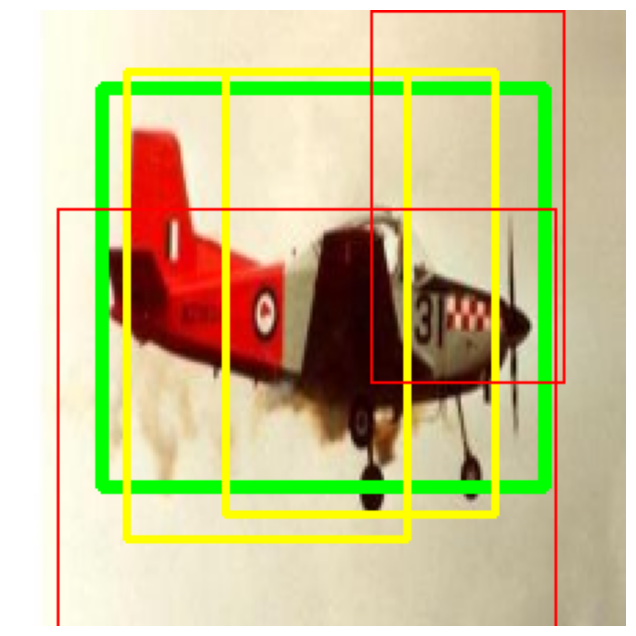

In [28]:
TEST_IMAGE_PATH = 'dataset/images/airplane/image_0002.jpg'
visualize_rpn_proposals(TEST_IMAGE_PATH, rpn_model, backbone)

# Summary

In this tutorial, we learned how to implement the **Region Proposal Network (RPN)** in **PyTorch**. First, we explored how RPN uses the **Feature Map** generated by the **Backbone** and, with the help of **Anchor Boxes**, identifies regions that are likely to contain objects.

Then, we studied the role of the **RPN Head** in predicting the probability of object presence (**Objectness Score**) and refining the coordinates of **Bounding Boxes**. After that, we examined how duplicate bounding boxes are removed using **Non-Maximum Suppression (NMS)**.

We also covered the practical steps, including:

- Preparing the Dataset
- Building the DataLoader
- Using a Backbone (such as ResNet-18)
- Freezing the Backbone weights
- Creating the Anchor Generator
- Defining the RPN Head
- Setting important Hyperparameters
- Training the model
- Running the Prediction phase

Finally, the RPN generates a set of **proposed Bounding Boxes** (Region Proposals), which are then passed to the next stage, such as the **Fast R-CNN Head**, where the class of each object is determined and the bounding box coordinates are further refined with higher accuracy.